In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.9 MB/s eta 0:00:00



image 1/1 /content/perro_gato_silla.jpg: 448x640 1 cat, 1 dog, 1 chair, 1 refrigerator, 39.5ms
Speed: 2.0ms preprocess, 39.5ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)


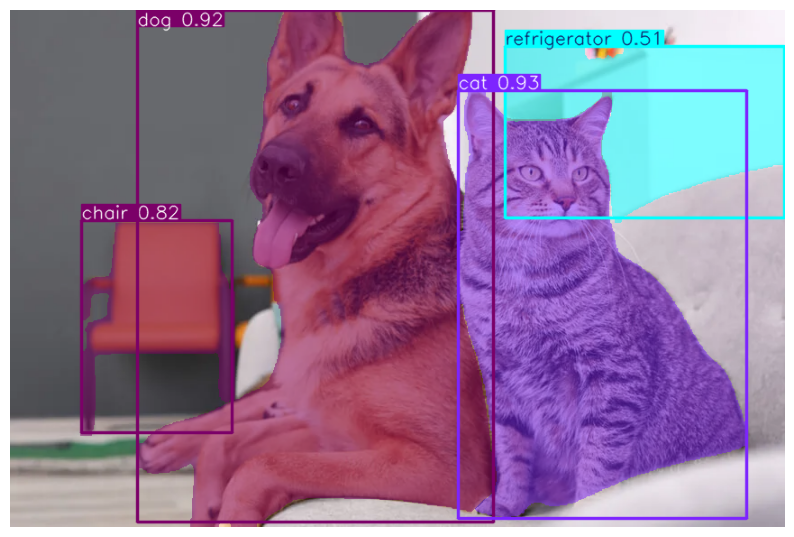

cat 0.933 [xyxy=(497.2, 90.4, 817.3, 564.6)] mask_area_px=87063
dog 0.923 [xyxy=(141.7, 1.2, 536.6, 568.0)] mask_area_px=126663
chair 0.823 [xyxy=(79.5, 234.3, 246.4, 469.7)] mask_area_px=22189
refrigerator 0.513 [xyxy=(549.8, 41.1, 859.4, 231.9)] mask_area_px=36844


In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen_entrada = "/content/perro_gato_silla.jpg"

model = YOLO("yolo11m-seg.pt")

results = model.predict(source=imagen_entrada, device=0, conf=0.5, imgsz=640, verbose=True)
r = results[0]

annotated = r.plot()[:, :, ::-1]

plt.figure(figsize=(10, 7))
plt.imshow(annotated)
plt.axis("off")
plt.show()

if r.masks is None:
    print("No se detectaron máscaras de segmentación en la imagen.")
else:
    img_bgr = cv2.imread(imagen_entrada)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    for i in range(len(r.boxes)):
        cls = int(r.boxes.cls[i].item())
        conf = float(r.boxes.conf[i].item())

        x1, y1, x2, y2 = map(float, r.boxes.xyxy[i].tolist())

        mask = r.masks.data[i].detach().cpu().numpy().astype(np.uint8)

        h, w = img_rgb.shape[:2]
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        area_px = int(mask.sum())

        print(
            f"{model.names[cls]} {conf:.3f} "
            f"[xyxy=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})] "
            f"mask_area_px={area_px}"
        )


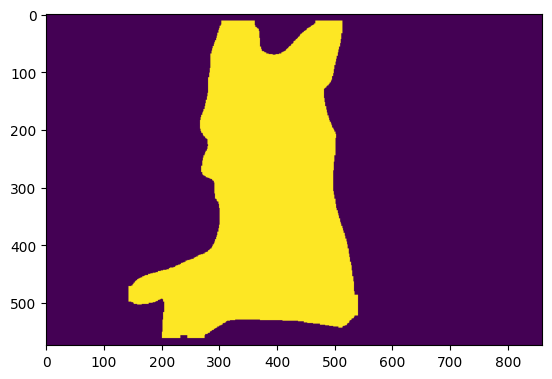

In [5]:
mask = r.masks.data[1].detach().cpu().numpy().astype(np.uint8)

h, w = img_rgb.shape[:2]
mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
plt.imshow(mask)


image 1/1 /content/autos_motos.jpeg: 384x640 1 person, 5 cars, 1 motorcycle, 69.2ms
Speed: 1.6ms preprocess, 69.2ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


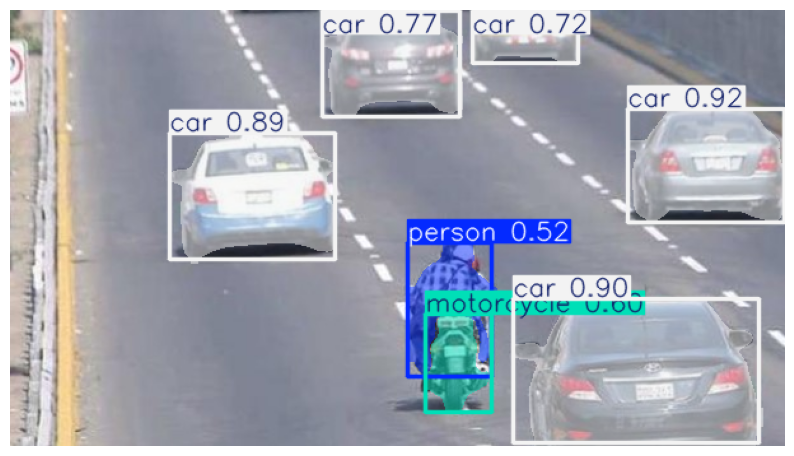

car 0.919 [xyxy=(485.4, 79.0, 608.4, 167.5)] mask_area_px=8401
car 0.904 [xyxy=(395.8, 227.9, 588.4, 340.1)] mask_area_px=18039
car 0.886 [xyxy=(125.5, 97.4, 255.7, 196.2)] mask_area_px=9459
car 0.767 [xyxy=(245.6, 1.0, 353.1, 84.4)] mask_area_px=6776
car 0.719 [xyxy=(363.7, 1.0, 446.2, 42.7)] mask_area_px=2907
motorcycle 0.605 [xyxy=(326.1, 239.2, 378.1, 316.6)] mask_area_px=2369
person 0.525 [xyxy=(312.3, 183.7, 378.7, 288.4)] mask_area_px=3455


In [6]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen_entrada = "/content/autos_motos.jpeg"

model = YOLO("yolo11m-seg.pt")

results = model.predict(source=imagen_entrada, device=0, conf=0.5, imgsz=640, verbose=True)
r = results[0]

annotated = r.plot()[:, :, ::-1]

plt.figure(figsize=(10, 7))
plt.imshow(annotated)
plt.axis("off")
plt.show()

if r.masks is None:
    print("No se detectaron máscaras de segmentación en la imagen.")
else:
    img_bgr = cv2.imread(imagen_entrada)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    for i in range(len(r.boxes)):
        cls = int(r.boxes.cls[i].item())
        conf = float(r.boxes.conf[i].item())

        x1, y1, x2, y2 = map(float, r.boxes.xyxy[i].tolist())

        mask = r.masks.data[i].detach().cpu().numpy().astype(np.uint8)

        h, w = img_rgb.shape[:2]
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        area_px = int(mask.sum())

        print(
            f"{model.names[cls]} {conf:.3f} "
            f"[xyxy=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})] "
            f"mask_area_px={area_px}"
        )


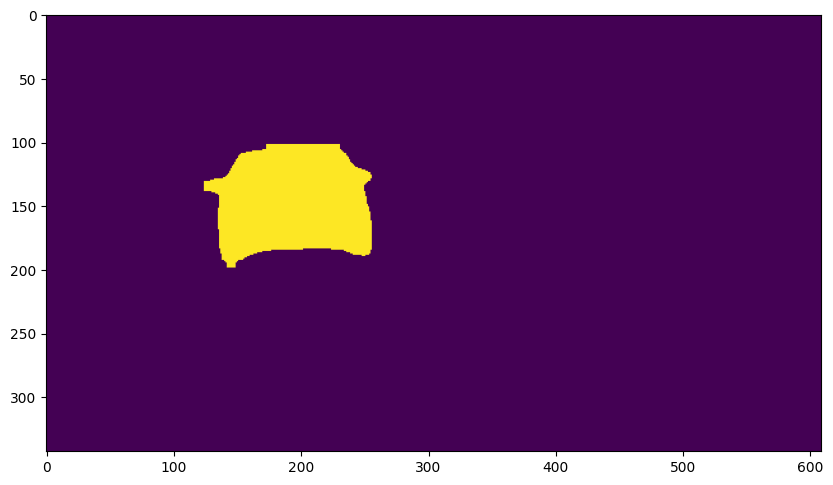

In [11]:
plt.figure(figsize=(10, 7))
mask = r.masks.data[2].detach().cpu().numpy().astype(np.uint8)

h, w = img_rgb.shape[:2]
mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
plt.imshow(mask)